# Cepheid — RV analysis

`cepheid_build.ipynb` produces a single 5000–5020 Å spectral fragment per LD
variant (no per-line synthesis). This notebook recovers radial velocities from
that fragment two ways:

1. **Full window** — cross-correlate the whole 20 Å fragment.
2. **Per-line windows** — cross-correlate small windows around Fe I lines
   chosen from the NLTE GES synthesis linelist. The half-width of each window is fitted
   independently per line by minimising the RMS between the recovered RV
   curve and the on-mesh true pulsation velocity.

Both are then compared against the on-mesh pulsation velocity (the "ground
truth") and across linear-LD coefficients to study the projection factor.


In [1]:
import sys, os
from pathlib import Path
import sys
sys.path.append('/Users/mjablons/code/spice/src')
import warnings
import numpy as np
import jax.numpy as jnp
import matplotlib.pyplot as plt
import pandas as pd
from tqdm import tqdm
from astropy.io import fits
from astropy.table import Table
from scipy.interpolate import interp1d
from scipy.optimize import curve_fit
from scipy.signal.windows import tukey

from spice.cepheid_bundles import CepheidBundle, LineSpectra, load_pickle

%matplotlib inline

## Load bundles and spectra

Each `spectra_dataset[variant]` is a dict keyed by line center; with the new build there is exactly one entry per variant — the full fragment, with `wavelengths` spanning 5000–5020 Å.


In [2]:
bundles = load_pickle('/Users/mjablons/code/spice/data/cepheid_grid/cep_DeltaCep_bundles.pkl')
spectra_dataset = load_pickle('/Users/mjablons/code/spice/data/cepheid_grid/cep_DeltaCep_spectra.pkl')

In [3]:
# bundles = load_pickle('cepheid_bundles_vmicro.pkl')
# spectra_dataset = load_pickle('cepheid_spectra_vmicro.pkl')

print('Bundles:        ', list(bundles.keys()))
print('Spectra variants:', list(spectra_dataset.keys()))

_first_variant = next(iter(spectra_dataset))
_first_ls = next(iter(spectra_dataset[_first_variant].values()))
print(
    f'Fragment for {_first_variant!r}: '
    f'{float(_first_ls.wavelengths.min()):.2f}–{float(_first_ls.wavelengths.max()):.2f} Å '
    f'({len(_first_ls.wavelengths)} points, {len(_first_ls.spectra)} snapshots)'
)

# Display names for emulator / spectrum variants (pickle keys → plot labels).
SPECTRA_VARIANT_RENAME = {
    "with_ld": "linear_interpolator",
    "harps": "harps_transformer",
    "iron_line": "iron_line_transformer",
}
BUNDLE_RENAME = {
    "intensity": "linear_interpolator",
    "harps": "harps_transformer",
    "iron_line": "iron_line_transformer",
}
REF_BUNDLE = "linear_interpolator"   # mesh / V_puls truth (from ``intensity`` bundle)
REF_VARIANT = REF_BUNDLE             # alias used throughout for bundle lookups

_REF_SPECTRA_KEYS = (
    "linear_interpolator", "with_ld", "intensity_mu1_linear_0.000",
)


def _rename_variant_keys(
    data: dict[str, object], rename: dict[str, str],
) -> dict[str, object]:
    return {rename.get(k, k): v for k, v in data.items()}


spectra_dataset = _rename_variant_keys(spectra_dataset, SPECTRA_VARIANT_RENAME)
bundles = _rename_variant_keys(bundles, BUNDLE_RENAME)

REF_SPECTRA = next(k for k in _REF_SPECTRA_KEYS if k in spectra_dataset)
print(f'Reference bundle: {REF_BUNDLE!r}  |  reference spectra: {REF_SPECTRA!r}')


Bundles:         ['intensity', 'harps', 'iron_line', 'intensity_mu1']
Spectra variants: ['intensity_mu1_linear_0.000', 'intensity_mu1_linear_1.000', 'intensity_mu1_linear_0.053', 'intensity_mu1_linear_0.105', 'intensity_mu1_linear_0.158', 'intensity_mu1_linear_0.211', 'intensity_mu1_linear_0.263', 'intensity_mu1_linear_0.316', 'intensity_mu1_linear_0.368', 'intensity_mu1_linear_0.421', 'intensity_mu1_linear_0.474', 'intensity_mu1_linear_0.526', 'intensity_mu1_linear_0.579', 'intensity_mu1_linear_0.632', 'intensity_mu1_linear_0.684', 'intensity_mu1_linear_0.737', 'intensity_mu1_linear_0.789', 'intensity_mu1_linear_0.842', 'intensity_mu1_linear_0.895', 'intensity_mu1_linear_0.947']
Fragment for 'intensity_mu1_linear_0.000': 5000.00–5020.00 Å (2000 points, 100 snapshots)
Reference bundle: 'linear_interpolator'  |  reference spectra: 'intensity_mu1_linear_0.000'


## Phase grid & SPIPS3 reference


In [4]:
PERIOD = 5.366265401100268
TIMESERIES = jnp.linspace(0, PERIOD, 100)
phases = (TIMESERIES / PERIOD) % 1.0
PHASE_NUMPY = np.asarray(phases)

with fits.open('delta_cep.fits', ignore_missing_simple=True) as hdul:
    pulsation_data = Table(hdul[2].data)


## Pulsation-velocity sanity check

Area-weighted mean of the radial component of the per-face pulsation
velocity on the `intensity` bundle, vs SPIPS3 `Vpuls`. For a radially
pulsating photosphere this is exactly `dR/dt` (intrinsic, not LOS-projected
and not magnitude-based).


In [5]:
def radial_surface_mean(model, vector_attr: str) -> float:
    """Area-weighted mean of the radial projection of a per-face vector field.

    For a vector field v(face), this returns

        <v_r> = sum_f area_f (v_f . n_f) / sum_f area_f

    where n_f is the outward radial unit vector at face f. For a strictly
    radial pulsation (l=0, m=0) this equals the radial speed at the surface
    -- i.e. dR/dt -- which is the intrinsic quantity SPIPS3 reports as Vpuls.

    Notes:
        * Computed over the full sphere, not the visible hemisphere: Vpuls is
          intrinsic. Disk-projected (LOS) integrals are a separate quantity.
        * Uses the radial component of the vector, not its magnitude. The
          magnitude inflates the answer whenever the field has tangential
          components (rotation drift, non-radial pulsation modes).
    """
    centers = np.asarray(model.centers)
    vectors = np.asarray(getattr(model, vector_attr))
    areas = np.asarray(model.areas)
    normals = centers / np.linalg.norm(centers, axis=1, keepdims=True)
    radial = np.sum(vectors * normals, axis=1)
    return float(np.average(radial, weights=areas))


pulsation_velocities = np.array(
    [radial_surface_mean(m, 'pulsation_velocities') for m in bundles[REF_VARIANT].snapshots]
)
pulsation_offsets = np.array(
    [radial_surface_mean(m, 'center_pulsation_offsets') for m in bundles[REF_VARIANT].snapshots]
)


In [6]:
m = bundles['linear_interpolator'].snapshots[0]

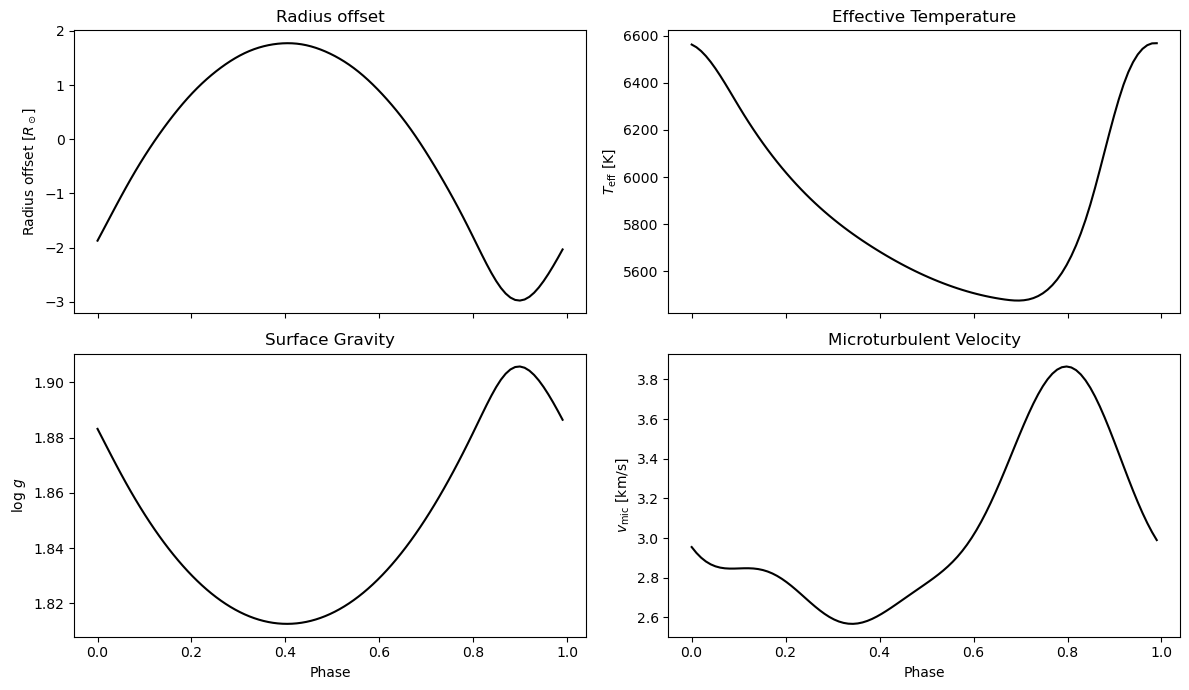

In [7]:
fig, axs = plt.subplots(2, 2, figsize=(12, 7), sharex=True)

# Plot radius offset
axs[0, 0].plot(phases[:-1], pulsation_offsets[:-1], color='black', label='Radius offset [$R_\\odot$]')
axs[0, 0].set_ylabel('Radius offset [$R_\\odot$]')
axs[0, 0].set_title('Radius offset')

# Plot Teff
teffs = np.array([np.average(m.parameters[:, 0], weights=np.asarray(m.areas)) for m in bundles[REF_VARIANT].snapshots])
axs[0, 1].plot(phases[:-1], teffs[:-1], color='black', label='$T_{\\rm eff}$ [K]')
axs[0, 1].set_ylabel('$T_{\\rm eff}$ [K]')
axs[0, 1].set_title('Effective Temperature')

# Plot logg
loggs = np.array([np.average(m.parameters[:, 1], weights=np.asarray(m.areas)) for m in bundles[REF_VARIANT].snapshots])
axs[1, 0].plot(phases[:-1], loggs[:-1], color='black', label='log $g$')
axs[1, 0].set_ylabel('log $g$')
axs[1, 0].set_title('Surface Gravity')

# Plot vmic
vmics = np.array([np.average(m.parameters[:, 3], weights=np.asarray(m.areas)) for m in bundles[REF_VARIANT].snapshots])
axs[1, 1].plot(phases[:-1], vmics[:-1], color='black', label='$v_{\\rm mic}$ [km/s]')
axs[1, 1].set_ylabel('$v_{\\rm mic}$ [km/s]')
axs[1, 1].set_title('Microturbulent Velocity')

for ax in axs[1, :]:
    ax.set_xlabel('Phase')
    
fig.savefig('pulsation_data.pdf', bbox_inches='tight')

plt.tight_layout()
plt.show()

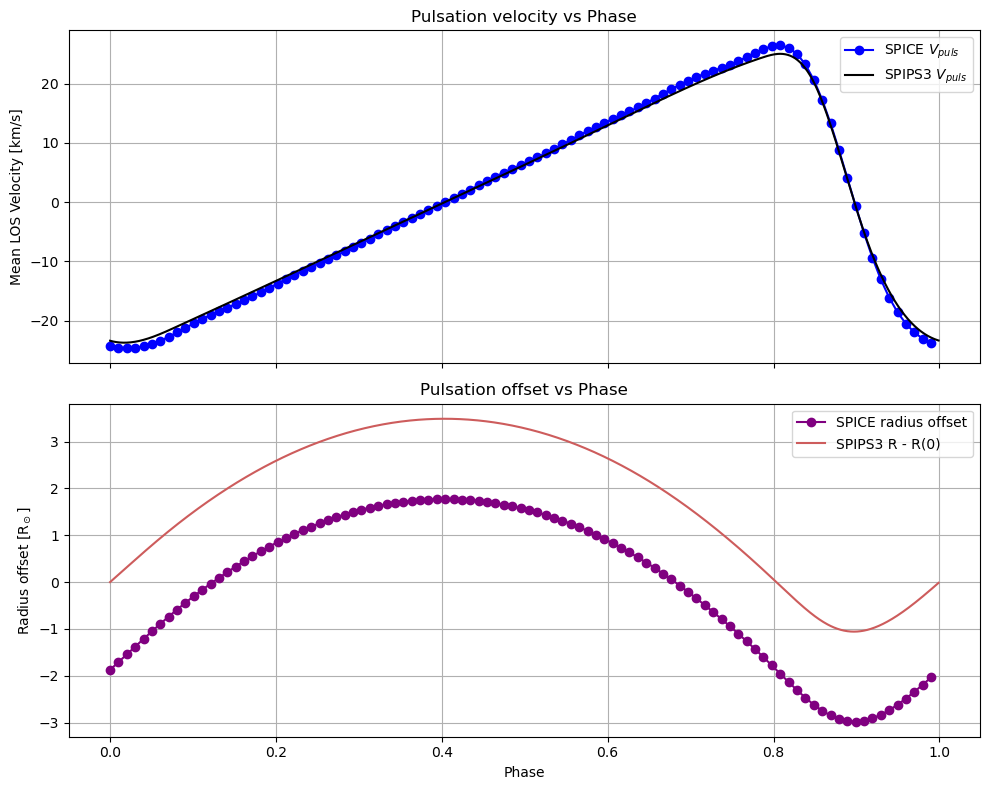

In [8]:
fig, ax = plt.subplots(2, 1, figsize=(10, 8), sharex=True)
ax[0].plot(phases[:-1], pulsation_velocities[:-1], 'o-', color='blue', label=r'SPICE $V_{puls}$')
ax[0].plot(pulsation_data['PHASE'], pulsation_data['Vpuls'], color='black', label=r'SPIPS3 $V_{puls}$')
ax[0].set_ylabel('Mean LOS Velocity [km/s]'); ax[0].set_title('Pulsation velocity vs Phase')
ax[0].grid(True); ax[0].legend()

ax[1].plot(phases[:-1], pulsation_offsets[:-1], 'o-', color='purple', label='SPICE radius offset')
ax[1].plot(pulsation_data['PHASE'], pulsation_data['R'] - pulsation_data['R'][0],
           color='indianred', label='SPIPS3 R - R(0)')
ax[1].set_ylabel(r'Radius offset [R$_\odot$]'); ax[1].set_xlabel('Phase')
ax[1].set_title('Pulsation offset vs Phase'); ax[1].grid(True); ax[1].legend()
plt.tight_layout(); plt.show()


## Cross-correlation RV measurement

FFT-style normalised CCF on a log-wavelength grid, with a robust local-Gaussian peak refine. Positive RV = observed redshifted relative to template.


In [9]:
C_KMS = 299792.458


def _gaussian_peak_fit(v, c, top_frac=0.5, fallback=None):
    v = np.asarray(v, dtype=float)
    c = np.asarray(c, dtype=float)

    k = int(np.nanargmax(c))
    if fallback is None:
        fallback = float(v[k])

    c_med = float(np.nanmedian(c))
    c_max = float(c[k])
    if not np.isfinite(c_max) or c_max <= c_med:
        return fallback, np.nan

    thresh = c_med + top_frac * (c_max - c_med)
    left = k
    while left > 0 and c[left - 1] > thresh:
        left -= 1
    right = k
    while right < len(c) - 1 and c[right + 1] > thresh:
        right += 1

    pad = 2
    left = max(0, left - pad)
    right = min(len(c) - 1, right + pad)
    if right - left + 1 < 5:
        return fallback, np.nan

    vv = v[left:right + 1]
    cc = c[left:right + 1]

    def model(vv, A, v0, sigma, c0):
        return A * np.exp(-0.5 * ((vv - v0) / sigma) ** 2) + c0

    dv = abs(v[1] - v[0])
    width_guess = max(2 * dv, 0.25 * (vv[-1] - vv[0]))
    p0 = [c_max - c_med, fallback, width_guess, c_med]
    bounds = (
        [0.0, vv[0], dv / 2, -np.inf],
        [np.inf, vv[-1], max(vv[-1] - vv[0], dv), np.inf],
    )
    try:
        popt, pcov = curve_fit(model, vv, cc, p0=p0, bounds=bounds, maxfev=5000)
    except (RuntimeError, ValueError):
        return fallback, np.nan

    v0 = float(popt[1])
    if not np.isfinite(v0):
        return fallback, np.nan

    err = np.nan
    if pcov is not None and np.all(np.isfinite(pcov)):
        err = float(np.sqrt(pcov[1, 1]))
    return v0, err


def _normalized_lag_ccf(t, o, max_lag):
    lags = np.arange(-max_lag, max_lag + 1)
    ccf = np.full_like(lags, np.nan, dtype=float)
    for j, lag in enumerate(lags):
        if lag > 0:
            tt, oo = t[:-lag], o[lag:]
        elif lag < 0:
            tt, oo = t[-lag:], o[:lag]
        else:
            tt, oo = t, o
        good = np.isfinite(tt) & np.isfinite(oo)
        tt, oo = tt[good], oo[good]
        if tt.size < 5:
            continue
        tt = tt - np.mean(tt)
        oo = oo - np.mean(oo)
        denom = np.sqrt(np.sum(tt ** 2) * np.sum(oo ** 2))
        if denom > 0:
            ccf[j] = np.sum(tt * oo) / denom
    return lags, ccf


def calculate_rv_fft(template_flux, observed_flux, wavelengths,
                     velocity_max=150.0, oversample=4,
                     apodize=0.1, refine="gaussian",
                     gaussian_top_frac=0.5,
                     interp_kind="linear",
                     max_overlap_frac=0.5,
                     use_line_depth=True):
    wl = np.asarray(wavelengths, dtype=float)
    t_in = np.asarray(template_flux, dtype=float)
    o_in = np.asarray(observed_flux, dtype=float)

    if wl.size < 8 or t_in.size != wl.size or o_in.size != wl.size:
        raise ValueError("Inputs must be matching 1-D arrays, length >= 8.")
    if np.any(np.diff(wl) <= 0):
        raise ValueError("wavelengths must be strictly increasing.")

    lnwl_in = np.log(wl)
    n = int(oversample * len(wl))
    n += n % 2
    lnlam = np.linspace(lnwl_in[0], lnwl_in[-1], n)
    dv_pix = C_KMS * (lnlam[1] - lnlam[0])

    def _resample(y):
        return interp1d(lnwl_in, y, kind=interp_kind, bounds_error=False, fill_value=np.nan)(lnlam)

    t = _resample(t_in)
    o = _resample(o_in)
    good = np.isfinite(t) & np.isfinite(o)
    if good.sum() < 8:
        raise ValueError("Too few finite overlapping pixels.")
    idx = np.flatnonzero(good)
    seg = slice(idx[0], idx[-1] + 1)
    t = t[seg].copy()
    o = o[seg].copy()
    for a in (t, o):
        bad = ~np.isfinite(a)
        if bad.any():
            a[bad] = np.nanmedian(a)

    if use_line_depth:
        t = 1.0 - t
        o = 1.0 - o

    t = t - np.nanmedian(t)
    o = o - np.nanmedian(o)

    n_eff = t.size
    if apodize > 0:
        w = tukey(n_eff, apodize)
        t *= w
        o *= w

    max_lag_req = int(np.ceil(velocity_max / dv_pix))
    max_lag_overlap = int(np.floor(n_eff * max_overlap_frac))
    max_lag = min(max_lag_req, max_lag_overlap)
    if max_lag < 2:
        raise ValueError(
            f"n_eff={n_eff} too small for velocity_max={velocity_max} km/s at dv_pix={dv_pix:.3f} km/s."
        )

    lags, ccf = _normalized_lag_ccf(t, o, max_lag)
    velocities = lags * dv_pix
    k = int(np.nanargmax(ccf))
    best_velocity = float(velocities[k])
    best_velocity_err = np.nan

    at_edge = k <= 1 or k >= len(ccf) - 2
    if at_edge:
        warnings.warn(
            f"CCF peak at edge: v={best_velocity:.2f} km/s. Increase velocity_max or inspect this window.",
            RuntimeWarning,
        )
        return best_velocity, best_velocity_err, ccf, velocities

    if refine == "parabolic":
        y0, y1, y2 = ccf[k - 1], ccf[k], ccf[k + 1]
        d = y0 - 2.0 * y1 + y2
        if np.isfinite(d) and d < 0:
            best_velocity += 0.5 * (y0 - y2) / d * dv_pix
    elif refine == "gaussian":
        v_fit, e_fit = _gaussian_peak_fit(velocities, ccf, top_frac=gaussian_top_frac, fallback=best_velocity)
        if np.isfinite(v_fit) and velocities[0] <= v_fit <= velocities[-1]:
            best_velocity = float(v_fit)
            best_velocity_err = e_fit

    return best_velocity, best_velocity_err, ccf, velocities


### Inject and recover a known velocity


In [10]:
ls_full = next(iter(spectra_dataset[REF_SPECTRA].values()))
template_wl   = np.asarray(ls_full.wavelengths)
template_flux = np.asarray(ls_full.template[:, 0] / ls_full.template[:, 1])

v_true = 25.0
wl_shifted = template_wl * (1 + v_true / C_KMS)
flux_obs = np.interp(template_wl, wl_shifted, template_flux, left=1.0, right=1.0)

v_rec, v_err, _, _ = calculate_rv_fft(template_flux, flux_obs, template_wl)
print(f'injected {v_true:+.2f}, recovered {v_rec:+.3f} ± {v_err:.3f} km/s')


injected +25.00, recovered +25.040 ± 0.007 km/s


## Selected Fe I lines (NLTE GES linelist)

Lines are taken only from the synthesis linelist
`data/nlte_ges_linelist_jmg16jan2026_I_II` (Fe I NLTE block, λ in air Å).
Within the 5000–5020 Å fragment we keep the deepest, well-separated features:
greedy selection by template depth with a minimum spacing of 5 Å so per-line CCF
windows stay single-line (same logic as the earlier hand-picked trio, but
wavelengths and EP come from the list used by the zarr grid).

The middle feature uses **5007.274 Å** (log gf ≈ −0.20), not 5007.212 Å — the
latter is not present in the NLTE/GES list.

In [11]:
HERE = Path.cwd().resolve()
# NLTE_GES_LINELIST = HERE.parents[1] / "data/nlte_ges_linelist_jmg16jan2026_I_II"
# if not NLTE_GES_LINELIST.is_file():
#     NLTE_GES_LINELIST = HERE / "data/nlte_ges_linelist_jmg16jan2026_I_II"
# if not NLTE_GES_LINELIST.is_file():
#     raise FileNotFoundError(
#         "NLTE GES linelist not found — run from repo root or tutorial/paper_results"
#     )
NLTE_GES_LINELIST = Path('/Users/mjablons/code/spice/data/nlte_ges_linelist_jmg16jan2026_I_II')
WL_FRAGMENT = (5000.0, 5020.0)
MIN_LINE_GAP_A = 5.0   # Å between selected centres (matches old ~5.35 Å spacing)
MAX_FE_I_LINES = 3


def load_nlte_fe1_lines(path: Path, wl_min: float, wl_max: float) -> list[tuple[float, float, float]]:
    """Return (λ_air, EP_eV, log_gf) for Fe I NLTE entries in [wl_min, wl_max]."""
    rows: list[tuple[float, float, float]] = []
    in_fe1 = False
    for line in path.read_text().splitlines():
        if line.strip() == "'Fe I    NLTE'":
            in_fe1 = True
            continue
        if line.strip() == "'Fe II   NLTE'":
            break
        if not in_fe1 or line.startswith("'") or not line.strip():
            continue
        parts = line.split()
        if len(parts) < 3:
            continue
        lam, ep, loggf = float(parts[0]), float(parts[1]), float(parts[2])
        if wl_min <= lam <= wl_max:
            rows.append((lam, ep, loggf))
    return rows


def _line_depth(template_wl: np.ndarray, template_flux: np.ndarray, lc: float) -> float:
    idx = int(np.argmin(np.abs(template_wl - lc)))
    return float(1.0 - template_flux[idx])


def select_fe1_lines(
    catalog: list[tuple[float, float, float]],
    template_wl: np.ndarray,
    template_flux: np.ndarray,
    *,
    min_gap: float,
    max_lines: int,
) -> list[tuple[str, float, float]]:
    """Greedy pick: deepest lines first, at least ``min_gap`` apart."""
    scored = [
        (lam, ep, loggf, _line_depth(template_wl, template_flux, lam))
        for lam, ep, loggf in catalog
    ]
    scored.sort(key=lambda row: row[3], reverse=True)
    chosen: list[tuple[str, float, float]] = []
    for lam, ep, loggf, depth in scored:
        if any(abs(lam - lc) < min_gap for _, lc, _ in chosen):
            continue
        name = f"Fe I {lam:.3f}"
        chosen.append((name, lam, ep))
        if len(chosen) >= max_lines:
            break
    return chosen


ls_linear_interpolator = next(iter(spectra_dataset[REF_SPECTRA].values()))
template_wl = np.asarray(ls_linear_interpolator.wavelengths)
template_flux = np.asarray(ls_linear_interpolator.template[:, 0] / ls_linear_interpolator.template[:, 1])

_fe1_catalog = load_nlte_fe1_lines(NLTE_GES_LINELIST, *WL_FRAGMENT)
FE_I_LINES = sorted(
    select_fe1_lines(
        _fe1_catalog,
        template_wl,
        template_flux,
        min_gap=MIN_LINE_GAP_A,
        max_lines=MAX_FE_I_LINES,
    ),
    key=lambda row: row[1],
)

LINE_NAMES = [name for name, _, _ in FE_I_LINES]
LINE_CENTRES = np.array([lc for _, lc, _ in FE_I_LINES])
LINE_EPS = np.array([ep for _, _, ep in FE_I_LINES])

print(f"Linelist: {NLTE_GES_LINELIST.name}  ({len(_fe1_catalog)} Fe I lines in "
      f"{WL_FRAGMENT[0]:.0f}–{WL_FRAGMENT[1]:.0f} Å)")
print(f"{len(FE_I_LINES)} Fe I lines selected (min gap {MIN_LINE_GAP_A:.1f} Å):")
for name, lc, ep in FE_I_LINES:
    loggf = next(lg for lam, e, lg in _fe1_catalog if abs(lam - lc) < 1e-3)
    depth = _line_depth(template_wl, template_flux, lc)
    print(f"  {name:>16s}  λ = {lc:.3f} Å  EP = {ep:.3f} eV  loggf = {loggf:+.3f}  depth ≈ {depth:.3f}")

Linelist: nlte_ges_linelist_jmg16jan2026_I_II  (69 Fe I lines in 5000–5020 Å)
3 Fe I lines selected (min gap 5.0 Å):
     Fe I 5005.712  λ = 5005.712 Å  EP = 3.884 eV  loggf = -0.120  depth ≈ 0.429
     Fe I 5012.068  λ = 5012.068 Å  EP = 0.859 eV  loggf = -2.642  depth ≈ 0.250
     Fe I 5018.027  λ = 5018.027 Å  EP = 3.635 eV  loggf = -2.553  depth ≈ 0.559


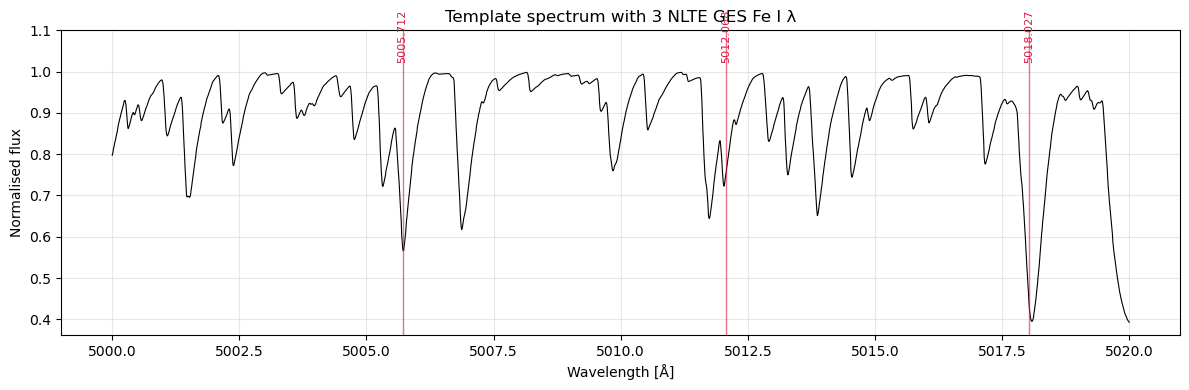

In [12]:
fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(template_wl, template_flux, color='black', lw=0.8, label='Template (with LD)')
for name, lc, ep in FE_I_LINES:
    ax.axvline(lc, color='crimson', alpha=0.6, lw=1.0)
    ax.text(lc, 1.02, name.replace('Fe I ', ''),
            rotation=90, ha='center', va='bottom', fontsize=8, color='crimson')
ax.set_xlabel('Wavelength [Å]')
ax.set_ylabel('Normalised flux')
ax.set_ylim(top=1.10)
ax.set_title(f'Template spectrum with {len(FE_I_LINES)} NLTE GES Fe I λ')
ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

Visible-disk mean LOS velocity at template (t=0): +0.00 km/s
SPICE area-mean radial V_puls at snapshot 0:          -24.27 km/s
  (if |mean LOS| ≪ |RV_eq| per line below, residual offset is mostly blends)

            line     λ_list      λ_min    λ_parab        Δλ     RV_eq
   Fe I 5005.712   5005.712   5005.723      1.022  +5004.6903  +299731.27 km/s
   Fe I 5012.068   5012.068   5011.746   5011.746   +0.3219    +19.25 km/s
   Fe I 5018.027   5018.027   5018.089   5018.089   -0.0624     -3.73 km/s


/var/folders/7r/n_x0ntj511v_0gt816mgrc1c0000gq/T/ipykernel_85255/40488842.py:17: RankWarning: Polyfit may be poorly conditioned
  coef = np.polyfit(x, y, 2)
/var/folders/7r/n_x0ntj511v_0gt816mgrc1c0000gq/T/ipykernel_85255/40488842.py:17: RankWarning: Polyfit may be poorly conditioned
  coef = np.polyfit(x, y, 2)
/var/folders/7r/n_x0ntj511v_0gt816mgrc1c0000gq/T/ipykernel_85255/40488842.py:17: RankWarning: Polyfit may be poorly conditioned
  coef = np.polyfit(x, y, 2)


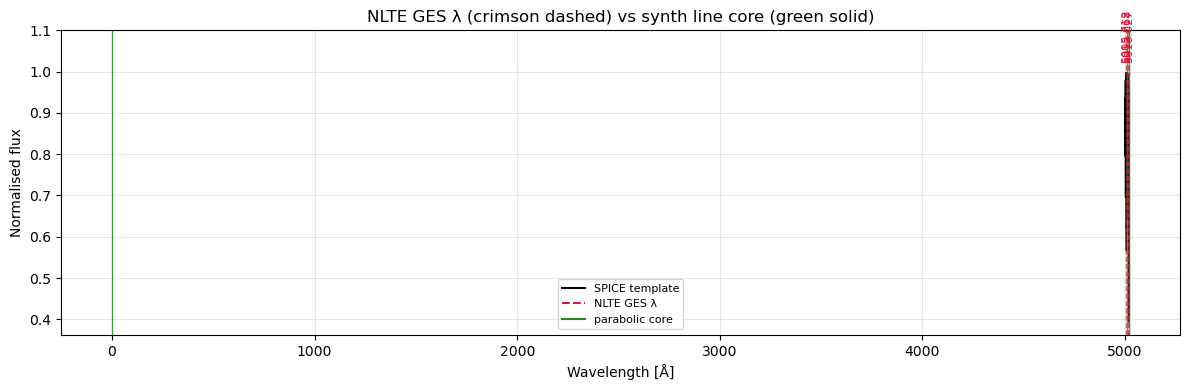

In [13]:
# Diagnostic: NLTE linelist λ (crimson) vs parabolic line-core fit on the template.
# Same offset in cepheid_analysis_no_rot ⇒ rotation is not the dominant cause.
# Residual shifts are mostly blends / asymmetric profiles, not wrong list wavelengths
# (selected centres are synthesis linelist entries).
C_KMS = 299792.458
_half_win = 1.5  # Å search window around each line centre


def _parabolic_core(wl, flux):
    """Parabolic fit to the deepest three pixels for a sub-grid core estimate."""
    i0 = int(np.argmin(flux))
    i1, i2 = max(i0 - 1, 0), min(i0 + 1, len(flux) - 1)
    x = wl[[i1, i0, i2]]
    y = flux[[i1, i0, i2]]
    if len(np.unique(x)) < 3:
        return float(wl[i0])
    coef = np.polyfit(x, y, 2)
    if coef[0] >= 0:
        return float(wl[i0])
    return float(-coef[1] / (2 * coef[0]))


template_mesh = bundles[REF_VARIANT].template
_vis = np.asarray(template_mesh.mus) > 0
_v_los = np.asarray(template_mesh.los_velocities)[_vis]
_areas = np.asarray(template_mesh.visible_cast_areas)[_vis]
_v_los_mean = float(np.average(_v_los, weights=_areas))
_vpuls_t0 = float(pulsation_velocities[0])
print(f'Visible-disk mean LOS velocity at template (t=0): {_v_los_mean:+.2f} km/s')
print(f'SPICE area-mean radial V_puls at snapshot 0:          {_vpuls_t0:+.2f} km/s')
print('  (if |mean LOS| ≪ |RV_eq| per line below, residual offset is mostly blends)\n')

_rows = []
for name, lc, ep in FE_I_LINES:
    mask = (template_wl >= lc - _half_win) & (template_wl <= lc + _half_win)
    wl_win = template_wl[mask]
    fl_win = template_flux[mask]
    lc_min = float(wl_win[int(np.argmin(fl_win))])
    lc_synth = _parabolic_core(wl_win, fl_win)
    dlam = lc - lc_synth  # >0 ⇒ linelist marker is redward of the fitted core
    rv_equiv = C_KMS * dlam / lc
    _rows.append((name, lc, lc_min, lc_synth, dlam, rv_equiv))

print(f"{'line':>16s}  {'λ_list':>9s}  {'λ_min':>9s}  {'λ_parab':>9s}  {'Δλ':>8s}  {'RV_eq':>8s}")
for name, lc, lc_m, lc_s, dlam, rv in _rows:
    print(f"{name:>16s}  {lc:9.3f}  {lc_m:9.3f}  {lc_s:9.3f}  {dlam:+8.4f}  {rv:+8.2f} km/s")

fig, ax = plt.subplots(figsize=(12, 4))
ax.plot(template_wl, template_flux, color='black', lw=0.8, label='Template (with LD, t=0)')
for name, lc, ep in FE_I_LINES:
    lc_synth = next(s for n, _, _, s, _, _ in _rows if n == name)
    ax.axvline(lc, color='crimson', ls='--', alpha=0.7, lw=1.0)
    ax.axvline(lc_synth, color='forestgreen', ls='-', alpha=0.8, lw=1.0)
    ax.text(lc, 1.02, name.replace('Fe I ', ''), rotation=90, ha='center', va='bottom',
            fontsize=8, color='crimson')
ax.set_xlabel('Wavelength [Å]')
ax.set_ylabel('Normalised flux')
ax.set_ylim(top=1.10)
ax.set_title('NLTE GES λ (crimson dashed) vs synth line core (green solid)')
from matplotlib.lines import Line2D
ax.legend(handles=[
    Line2D([], [], color='black', label='SPICE template'),
    Line2D([], [], color='crimson', ls='--', label='NLTE GES λ'),
    Line2D([], [], color='forestgreen', label='parabolic core'),
], fontsize=8)
ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()

## Per-line half-width optimisation

For each Fe I line, sweep candidate half-widths and pick the one that
minimises the RMS between the recovered RV curve and the on-mesh true
pulsation velocity (after a per-line linear projection-factor fit). No line
is treated as contaminating any other — we trust the manually-picked centres
and let the CCF use whatever spectral structure happens to fall inside each
window.


In [14]:
def measure_rvs_in_window(line_spectra: LineSpectra, wl_min: float, wl_max: float,
                          oversample: int = 5) -> np.ndarray:
    """Return RV (km/s) per snapshot inside [wl_min, wl_max]."""
    wl = np.asarray(line_spectra.wavelengths)
    mask = (wl >= wl_min) & (wl <= wl_max)
    wl_m = wl[mask]
    if wl_m.size < 8:
        return np.full(len(line_spectra.spectra), np.nan)
    template = np.asarray(line_spectra.template[mask, 0] / line_spectra.template[mask, 1])
    rvs = [0.0]
    for spec in line_spectra.spectra[1:]:
        spec = np.asarray(spec)
        obs = spec[mask, 0] / spec[mask, 1]
        try:
            rv, _, _, _ = calculate_rv_fft(template, obs, wl_m, oversample=oversample)
        except (ValueError, RuntimeError):
            rv = np.nan
        rvs.append(rv)
    return np.array(rvs)


def _best_p(rv, truth):
    rv = np.asarray(rv, dtype=float)[1:]
    truth = np.asarray(truth, dtype=float)[1:]
    good = np.isfinite(rv) & np.isfinite(truth)
    if good.sum() < 3 or np.sum(rv[good] ** 2) == 0:
        return np.nan, np.nan
    p = float(np.sum(rv[good] * truth[good]) / np.sum(rv[good] ** 2))
    res = truth[good] - p * rv[good]
    return p, float(np.sqrt(np.mean(res ** 2)))


truth_curve = pulsation_velocities - pulsation_velocities[0]

# A window of half-width hw covers ±(c·hw/λ) km/s in wavelength. The default CCF
# uses max_overlap_frac=0.5, so the lag grid only spans HALF that — i.e. the CCF
# can search ±(c·hw/λ)/2 km/s. To resolve a peak at ±RV_max without railing out,
# we need hw ≥ 1.5 · RV_max · λ / c (50% margin).
RV_MAX = float(np.max(np.abs(truth_curve)))
WL_REF = float(template_wl.mean())
MIN_SAFE_HW = 1.5 * RV_MAX * WL_REF / C_KMS

HALF_WIDTH_GRID_FULL = np.array([
    0.08, 0.10, 0.12, 0.15, 0.18, 0.20, 0.22, 0.25, 0.28,
    0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60, 0.70, 0.80,
    0.90, 1.00, 1.20, 1.50,
])
HALF_WIDTH_GRID = HALF_WIDTH_GRID_FULL[HALF_WIDTH_GRID_FULL >= MIN_SAFE_HW]
dropped = HALF_WIDTH_GRID_FULL[HALF_WIDTH_GRID_FULL < MIN_SAFE_HW]
print(f'V_puls amplitude on visible hemisphere: ±{RV_MAX:.1f} km/s')
print(f'Minimum safe half-width @ {WL_REF:.0f} Å: {MIN_SAFE_HW:.3f} Å')
if len(dropped):
    print(f'Dropped {len(dropped)} widths that would rail the CCF lag grid: '
          f'{[float(x) for x in dropped]}')

full_rv_curve = measure_rvs_in_window(
    ls_linear_interpolator, float(template_wl.min()), float(template_wl.max())
)

per_line_records = []
per_line_curves = {}
with warnings.catch_warnings():
    # Per-snapshot edge warnings are expected for borderline-narrow widths;
    # the sweep will reject those widths via their RMS, no need to spam stderr.
    warnings.filterwarnings('ignore', category=RuntimeWarning,
                            message=r'CCF peak at edge')
    for name, lc, ep in tqdm(FE_I_LINES, desc='Fe I lines'):
        for hw in HALF_WIDTH_GRID:
            a, b = float(lc - hw), float(lc + hw)
            if a < template_wl.min() or b > template_wl.max():
                continue
            rv = measure_rvs_in_window(ls_linear_interpolator, a, b)
            p, rms_truth = _best_p(rv, truth_curve)
            rms_full = float(np.sqrt(np.nanmean((rv[1:] - full_rv_curve[1:]) ** 2)))
            per_line_records.append({
                'line': name, 'centre': lc, 'EP_eV': ep, 'half_width': float(hw),
                'p': p, 'rms_vs_truth': rms_truth, 'rms_vs_full': rms_full,
                'n_finite': int(np.sum(np.isfinite(rv[1:]))),
            })
            per_line_curves.setdefault(name, {})[float(hw)] = rv

per_line_df = pd.DataFrame(per_line_records)
per_line_df.head()

V_puls amplitude on visible hemisphere: ±50.7 km/s
Minimum safe half-width @ 5010 Å: 1.271 Å
Dropped 21 widths that would rail the CCF lag grid: [0.08, 0.1, 0.12, 0.15, 0.18, 0.2, 0.22, 0.25, 0.28, 0.3, 0.35, 0.4, 0.45, 0.5, 0.55, 0.6, 0.7, 0.8, 0.9, 1.0, 1.2]


Fe I lines: 100%|██████████| 3/3 [00:10<00:00,  3.39s/it]


,line,centre,EP_eV,half_width,p,rms_vs_truth,rms_vs_full,n_finite
0,Fe I 5005.712,5005.712,3.884,1.5,1.331333,1.005482,0.791401,99
1,Fe I 5012.068,5012.068,0.859,1.5,1.339378,0.799275,0.542402,99
2,Fe I 5018.027,5018.027,3.635,1.5,1.457215,0.209578,1.421856,99


In [15]:
# Best half-width per line: minimum RMS-vs-truth among widths where (almost)
# every snapshot converged.
per_line_summary_rows = []
for name, lc, ep in FE_I_LINES:
    sub = per_line_df[per_line_df['line'] == name].copy()
    sub_clean = sub[sub['n_finite'] >= 95]
    if sub_clean.empty:
        sub_clean = sub
    i = sub_clean['rms_vs_truth'].idxmin()
    r = sub_clean.loc[i]
    per_line_summary_rows.append({
        'line': name, 'EP_eV': ep, 'centre': lc,
        'best_half_width_Å': float(r['half_width']),
        'window_width_Å': 2 * float(r['half_width']),
        'p': float(r['p']),
        'RMS_vs_truth_kms': float(r['rms_vs_truth']),
        'RMS_vs_full_kms': float(r['rms_vs_full']),
        'n_finite': int(r['n_finite']),
    })

per_line_summary = pd.DataFrame(per_line_summary_rows).set_index('line')

# Per-line best half-width as a {name: hw} dict for use in the window definition.
LINE_HALF_WIDTHS = {row.name: float(row['best_half_width_Å'])
                    for _, row in per_line_summary.iterrows()}
per_line_summary


,EP_eV,centre,best_half_width_Å,window_width_Å,p,RMS_vs_truth_kms,RMS_vs_full_kms,n_finite
line,,,,,,,,
Fe I 5005.712,3.884,5005.712,1.5,3.0,1.331333,1.005482,0.791401,99
Fe I 5012.068,0.859,5012.068,1.5,3.0,1.339378,0.799275,0.542402,99
Fe I 5018.027,3.635,5018.027,1.5,3.0,1.457215,0.209578,1.421856,99


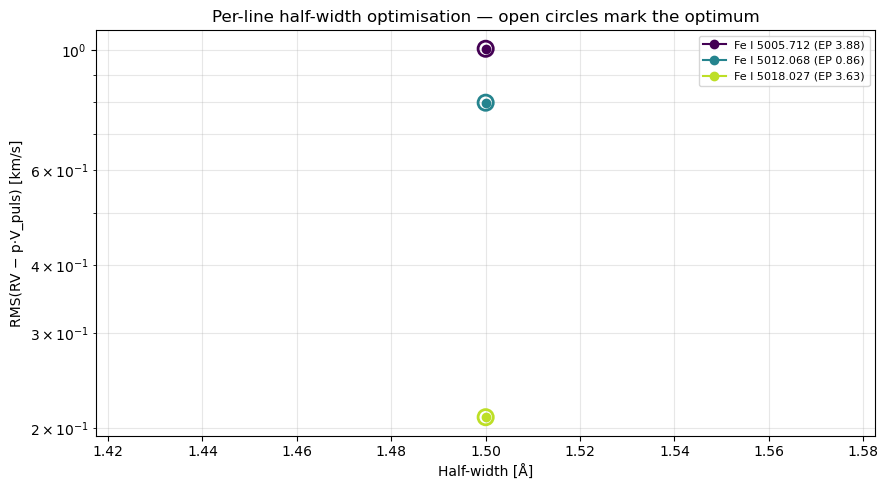

In [16]:
fig, ax = plt.subplots(figsize=(9, 5))
colors = plt.cm.viridis(np.linspace(0, 0.9, len(FE_I_LINES)))
for (name, lc, ep), color in zip(FE_I_LINES, colors):
    sub = per_line_df[per_line_df['line'] == name].sort_values('half_width')
    ax.plot(sub['half_width'], sub['rms_vs_truth'], 'o-', color=color,
            label=f'{name} (EP {ep:.2f})')
    best_hw = per_line_summary.loc[name, 'best_half_width_Å']
    best_rms = per_line_summary.loc[name, 'RMS_vs_truth_kms']
    ax.scatter([best_hw], [best_rms], s=120, facecolor='none',
               edgecolor=color, lw=2, zorder=5)

ax.set_yscale('log')
ax.set_xlabel('Half-width [Å]')
ax.set_ylabel('RMS(RV − p·V_puls) [km/s]')
ax.set_title('Per-line half-width optimisation — open circles mark the optimum')
ax.legend(fontsize=8, loc='best')
ax.grid(True, which='both', alpha=0.3)
plt.tight_layout(); plt.show()


## Define analysis windows

One full-fragment window plus, for each Fe I line, a window of the
optimised per-line half-width centred on the line.


In [17]:
windows = {'full': (float(template_wl.min()), float(template_wl.max()))}
for name, lc, ep in FE_I_LINES:
    hw = LINE_HALF_WIDTHS[name]
    key = name.replace('Fe I ', '')
    windows[key] = (float(lc - hw), float(lc + hw))

print('Analysis windows:')
for k, (a, b) in windows.items():
    print(f'  {k:>10s}: [{a:8.3f}, {b:8.3f}] Å  ({b - a:.2f} Å wide)')


Analysis windows:
        full: [5000.000, 5020.000] Å  (20.00 Å wide)
    5005.712: [5004.212, 5007.212] Å  (3.00 Å wide)
    5012.068: [5010.568, 5013.568] Å  (3.00 Å wide)
    5018.027: [5016.527, 5019.527] Å  (3.00 Å wide)


## Compute RVs for each window

For every (variant, window) pair we cross-correlate every snapshot against
the t = 0 template. The first snapshot is set to RV = 0 by definition (it
*is* the template).


In [18]:
variants = list(spectra_dataset.keys())
rv_table: dict[str, dict[str, np.ndarray]] = {variant: {} for variant in variants}

for variant in tqdm(variants, desc='variants'):
    ls = next(iter(spectra_dataset[variant].values()))
    for win_name, (a, b) in windows.items():
        rv_table[variant][win_name] = measure_rvs_in_window(ls, a, b)

rvs_linear_interpolator_full = rv_table[REF_SPECTRA]['full']
print('shape (snapshots,):', rvs_linear_interpolator_full.shape)


variants:   0%|          | 0/20 [00:00<?, ?it/s]

variants:   5%|▌         | 1/20 [00:23<07:32, 23.82s/it]


KeyboardInterrupt: 

## RV curves: full window vs per-line windows

Single-line windows are noisier than the full fragment, but bias differences
(per-line scatter, asymmetric line shape) are what we care about.


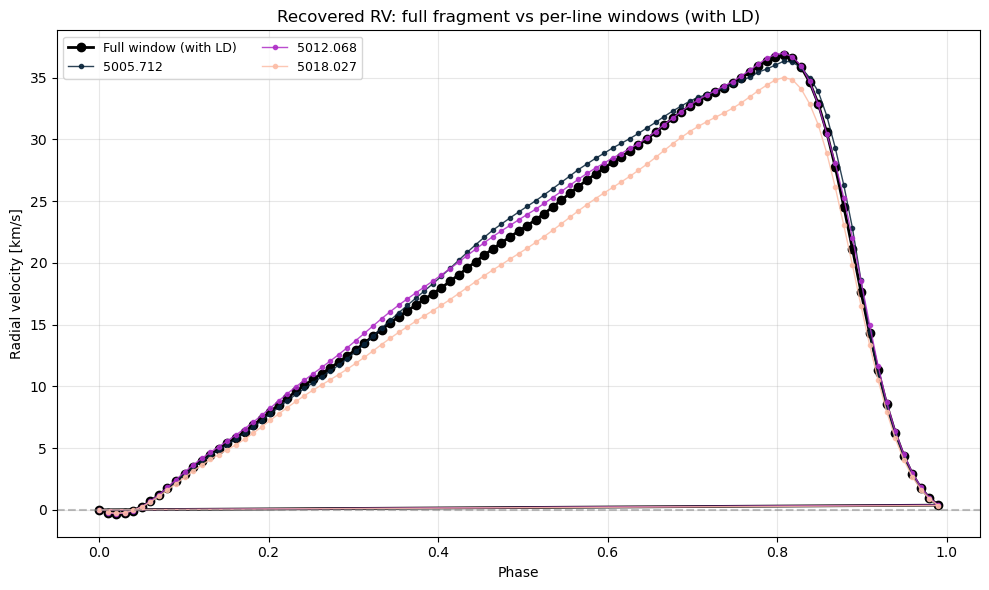

In [ ]:
import cmasher as cmr
cmap = cmr.bubblegum

fig, ax = plt.subplots(figsize=(10, 6))
ax.plot(phases[1:], rv_table[REF_SPECTRA]['full'][1:],
        color='black', lw=2, marker='o', label='Full window (with LD)')

line_keys = [k for k in windows if k != 'full']
norm = plt.Normalize(0, max(len(line_keys) - 1, 1))
for i, key in enumerate(line_keys):
    color = cmap(norm(i))
    ax.plot(phases[1:], rv_table[REF_SPECTRA][key][1:],
            color=color, lw=1.0, alpha=0.85, marker='.', label=key)

ax.axhline(0, color='gray', linestyle='--', alpha=0.5)
ax.set_xlabel('Phase')
ax.set_ylabel('Radial velocity [km/s]')
ax.set_title('Recovered RV: full fragment vs per-line windows (with LD)')
ax.legend(ncol=2, fontsize=9, loc='best')
ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()


## Trailed dynamic spectrum

Top: phase-coloured profile overlay of the full fragment. Bottom: residual
flux (per-snapshot minus the median profile) as a phase × wavelength map;
selected Fe I line centres marked.


## With LD vs no LD vs true pulsation velocity

`flux_linear_0.0` is the no-limb-darkening case; `flux_linear_1.0` is the
maximally-darkened linear-LD case; `linear_interpolator` uses the intensity-grid LD
baked into the emulator. The "true" curve is the on-mesh signed pulsation
velocity offset from t = 0.


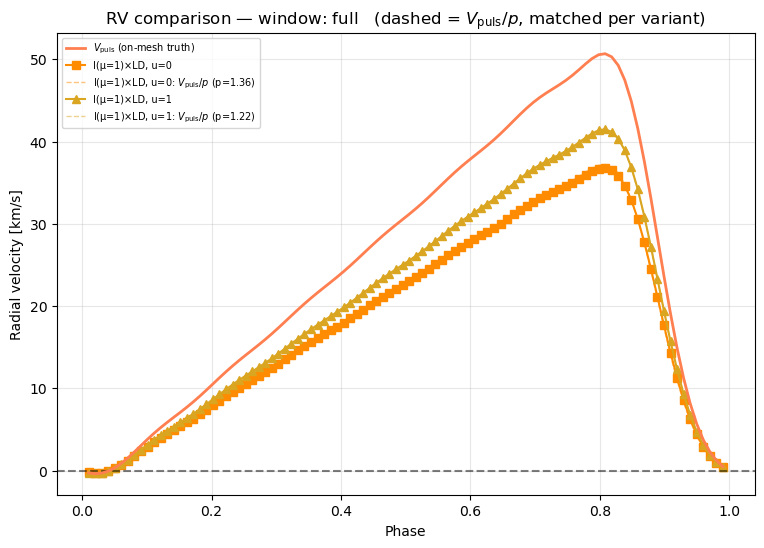

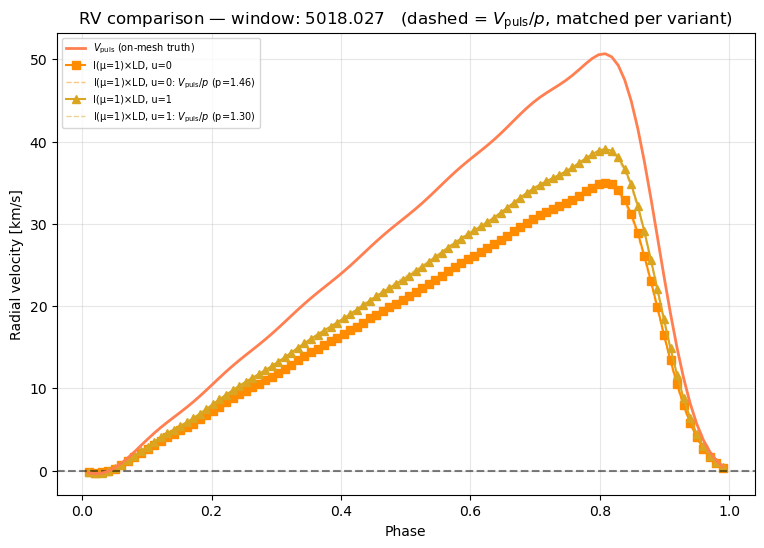

In [ ]:
def plot_rv_comparison(window_key: str, save: str | None = None,
                       scale_truth: bool = True):
    """Plot recovered RVs against the on-mesh pulsation velocity.

    With ``scale_truth=True`` (default), the truth curve is divided by the
    per-variant projection factor (slope estimator), so each model's truth
    line lands on top of its observed RV when the model is consistent.
    The on-mesh $V_{\\rm puls}$ is always shown (solid coral).
    """
    fig, ax = plt.subplots(figsize=(9, 6))
    pulsation_signed = pulsation_velocities - pulsation_velocities[0]
    phase_plot = phases[1:-1]

    ax.plot(phase_plot, pulsation_signed[1:-1], color='coral', lw=2.0, zorder=5,
            label=r'$V_{\rm puls}$ (on-mesh truth)')

    def _add(variant, color, marker, label, markersize=6):
        if variant not in rv_table:
            return
        rv = rv_table[variant][window_key]
        ax.plot(phase_plot, rv[1:-1], c=color, marker=marker,
                markersize=markersize, label=label)
        if scale_truth:
            p, _ = _best_p(rv, pulsation_signed)
            if np.isfinite(p) and p != 0:
                ax.plot(phase_plot, pulsation_signed[1:-1] / p,
                        c=color, ls='--', lw=1.0, alpha=0.5,
                        label=f'{label}: $V_{{\\rm puls}}/p$ (p={p:.2f})')

    _add('linear_interpolator', 'royalblue', 'o',
         'intensity grid (zarr LD)')
    _add('flux_linear_0.000', 'black', '*', 'flux grid, u=0', markersize=8)
    _add('flux_linear_1.000', 'dimgray', 'd', 'flux grid, u=1')
    _add('intensity_mu1_linear_0.000', 'darkorange', 's', 'I(μ=1)×LD, u=0')
    _add('intensity_mu1_linear_1.000', 'goldenrod', '^', 'I(μ=1)×LD, u=1')

    ax.axhline(0, color='black', linestyle='--', alpha=0.5)
    ax.set_xlabel('Phase'); ax.set_ylabel('Radial velocity [km/s]')
    title = f'RV comparison — window: {window_key}'
    if scale_truth:
        title += '   (dashed = $V_{\\rm puls}/p$, matched per variant)'
    ax.set_title(title)
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)
    if save:
        fig.savefig(save, dpi=300)
    return fig


plot_rv_comparison('full', save='radial_velocities.pdf')
plt.show()

# Same comparison for the cleanest single-line anchor.
deepest_name = per_line_summary['RMS_vs_truth_kms'].idxmin().replace('Fe I ', '')
plot_rv_comparison(deepest_name)
plt.show()

## Projection factor table

`p = V_pulsation / RV_observed`, mean over all phases (skipping the t = 0
template). Rows are analysis windows, columns are LD variants. The
classical Cepheid p-factor lives in the 1.2–1.5 range; departures across
windows quantify how line-window choice biases the recovered radius
integration.


In [ ]:
pulsation_signed = pulsation_velocities - pulsation_velocities[0]

window_keys = list(windows.keys())
rows = []
for win in window_keys:
    row = {'window': win, 'half_width_Å': 0.5 * (windows[win][1] - windows[win][0])}
    for variant in variants:
        rv = rv_table[variant][win]
        with np.errstate(divide='ignore', invalid='ignore'):
            ratio = pulsation_signed[1:] / rv[1:]
        row[variant] = float(np.nanmean(ratio))
    rows.append(row)

p_factor_df = pd.DataFrame(rows).set_index('window').reset_index()
p_factor_df

,window,half_width_Å,intensity_mu1_linear_0.000,intensity_mu1_linear_1.000,intensity_mu1_linear_0.053,intensity_mu1_linear_0.105,intensity_mu1_linear_0.158,intensity_mu1_linear_0.211,intensity_mu1_linear_0.263,intensity_mu1_linear_0.316,...,intensity_mu1_linear_0.474,intensity_mu1_linear_0.526,intensity_mu1_linear_0.579,intensity_mu1_linear_0.632,intensity_mu1_linear_0.684,intensity_mu1_linear_0.737,intensity_mu1_linear_0.789,intensity_mu1_linear_0.842,intensity_mu1_linear_0.895,intensity_mu1_linear_0.947
0,full,10.0,1.326996,1.203713,1.320972,1.314854,1.308603,1.302421,1.295835,1.289581,...,1.270095,1.263459,1.256684,1.250156,1.243463,1.236789,1.230155,1.223486,1.216869,1.210147
1,5005.712,1.5,1.310383,1.187762,1.303806,1.297010,1.290517,1.283606,1.276556,1.269971,...,1.249722,1.242971,1.236337,1.229958,1.223740,1.217436,1.211471,1.205370,1.199452,1.193563
2,5012.068,1.5,1.287450,1.163526,1.281488,1.275687,1.269219,1.262463,1.255512,1.248728,...,1.227788,1.220987,1.213740,1.207193,1.200594,1.194178,1.187816,1.181496,1.175416,1.169405
3,5018.027,1.5,1.434196,1.287760,1.427659,1.421046,1.414244,1.407357,1.400325,1.393167,...,1.370968,1.363229,1.355242,1.347292,1.339361,1.330812,1.322528,1.314088,1.305591,1.296728


### Regression-based projection factor

`mean(V_puls / RV_obs)` is biased: every snapshot where `RV_obs` crosses zero
produces a `1/RV_obs` blow-up that pollutes the mean. The unbiased estimator
for the slope of `V_puls = p · RV_obs` (no intercept) is

$$\hat p = \frac{\sum_t V_{\mathrm{puls},t}\, \mathrm{RV}_t}{\sum_t \mathrm{RV}_t^2}.$$

For linear LD against radial pulsation the analytical projection factor is
$p_{\mathrm{th}}(u) = 2(3-u)/(4-u)$, going from 1.500 at u=0 to 1.333 at u=1.


In [ ]:
def _slope_p(rv, truth, min_rv=1e-3):
    rv = np.asarray(rv, dtype=float)[1:]
    truth = np.asarray(truth, dtype=float)[1:]
    good = np.isfinite(rv) & np.isfinite(truth) & (np.abs(rv) > min_rv)
    if good.sum() < 5:
        return np.nan
    return float(np.sum(rv[good] * truth[good]) / np.sum(rv[good] ** 2))


slope_rows = []
for win in window_keys:
    row = {'window': win, 'half_width_Å': 0.5 * (windows[win][1] - windows[win][0])}
    for variant in variants:
        row[variant] = _slope_p(rv_table[variant][win], pulsation_signed)
    slope_rows.append(row)

p_slope_df = pd.DataFrame(slope_rows).set_index('window')
p_slope_df


,half_width_Å,intensity_mu1_linear_0.000,intensity_mu1_linear_1.000,intensity_mu1_linear_0.053,intensity_mu1_linear_0.105,intensity_mu1_linear_0.158,intensity_mu1_linear_0.211,intensity_mu1_linear_0.263,intensity_mu1_linear_0.316,intensity_mu1_linear_0.368,...,intensity_mu1_linear_0.474,intensity_mu1_linear_0.526,intensity_mu1_linear_0.579,intensity_mu1_linear_0.632,intensity_mu1_linear_0.684,intensity_mu1_linear_0.737,intensity_mu1_linear_0.789,intensity_mu1_linear_0.842,intensity_mu1_linear_0.895,intensity_mu1_linear_0.947
window,,,,,,,,,,,,,,,,,,,,,
full,10.0,1.362072,1.219970,1.355189,1.348292,1.341248,1.334192,1.326810,1.319522,1.312043,...,1.296913,1.289234,1.281675,1.273918,1.266136,1.258387,1.250675,1.242933,1.235272,1.227638
5005.712,1.5,1.331333,1.183725,1.323057,1.314438,1.305672,1.297126,1.288080,1.279295,1.270566,...,1.253733,1.245811,1.237977,1.230417,1.223282,1.216144,1.209282,1.202658,1.196118,1.189804
5012.068,1.5,1.339378,1.177370,1.332395,1.325155,1.316980,1.308456,1.299044,1.289939,1.280403,...,1.261394,1.252050,1.242535,1.233538,1.224764,1.216217,1.207971,1.199910,1.192111,1.184690
5018.027,1.5,1.457215,1.304231,1.450568,1.443704,1.436785,1.429655,1.422455,1.415041,1.407470,...,1.391985,1.383942,1.375707,1.367277,1.358760,1.350074,1.341170,1.332151,1.323005,1.313691


In [ ]:
# Linear-LD sweep setup. The classical analytical projection factor for a
# uniformly pulsating photosphere observed under linear LD is
# p(u) = 2(3-u)/(4-u), going from 1.500 (u=0) to 1.333 (u=1).
def p_theory(u):
    return 2.0 * (3.0 - u) / (4.0 - u)


u_grid = np.linspace(0, 1, 20)
linear_variants = [f'flux_linear_{u:.3f}' for u in u_grid]
intensity_mu1_variants = [f'intensity_mu1_linear_{u:.3f}' for u in u_grid]
present = [v for v in linear_variants if v in variants]
present_mu1 = [v for v in intensity_mu1_variants if v in variants]
u_present = np.array([float(v.split('_')[-1]) for v in present])
u_present_mu1 = np.array([float(v.split('_')[-1]) for v in present_mu1])
u_fine = np.linspace(0, 1, 101)
_phase_plot = phases[1:-1]

print(f'flux_linear sweep:   {len(present)} variants')
print(f'intensity_mu1 sweep: {len(present_mu1)} variants')
print(f"normal-mu reference: "
      f"{'linear_interpolator' if 'linear_interpolator' in rv_table else 'MISSING -- rebuild with `intensity` bundle'}")

flux_linear sweep:   0 variants
intensity_mu1 sweep: 20 variants
normal-mu reference: MISSING -- rebuild with `intensity` bundle


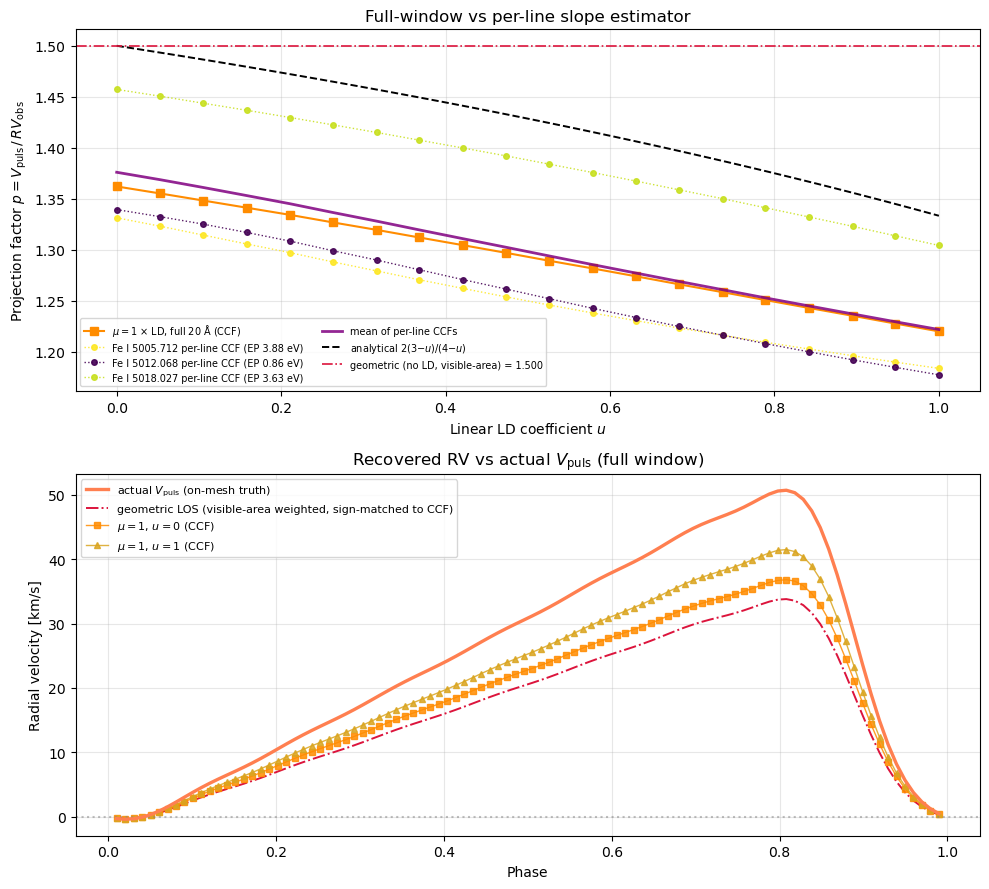

In [ ]:
# Three references for the projection-factor analysis:
#   1. mu = 1     -- intensity_mu1_linear sweep: disc-centre intensity rescaled
#                    by a synthetic linear LD law (variant per coefficient u).
#   2. normal mu  -- linear_interpolator: full intensity grid with each cell's
#                    own mu evaluated against the atmosphere's LD (single point,
#                    no synthetic LD coefficient).
#   3. actual V_puls -- area-weighted radial pulsation velocity on the mesh
#                       (the ground truth that defines p = V_puls / RV_obs).
_p_win = p_slope_df
_truth_rv = pulsation_velocities - pulsation_velocities[0]


def disc_los_velocity(model) -> float:
    """Visible-area-weighted LOS velocity (no intensity weighting).

    "No LD" disc projection: what an ideal CCF would recover if the photosphere
    had perfectly flat specific intensity across the disc. Useful as a geometric
    reference alongside the spectroscopic p-factors.
    """
    mus = np.asarray(model.mus)
    vis = mus > 0
    v_los = np.asarray(model.los_velocities)[vis]
    w = np.asarray(model.visible_cast_areas)[vis]
    return float(np.average(v_los, weights=w))


geometric_los = np.array(
    [disc_los_velocity(m) for m in bundles[REF_VARIANT].snapshots]
)
# Spice's `los_velocities` follow the standard astronomical sign convention
# (positive = receding), but the CCF measurement on the synthesised spectrum
# returns the opposite sign because `spice.spectrum.apply_vrad_log` shifts
# the per-face spectra in the inverted direction. Flip the geometric reference
# so it tracks the CCF curves -- this is purely a sign convention, the
# magnitude is unchanged.
geometric_rv = -(geometric_los - geometric_los[0])
p_geometric = _slope_p(geometric_rv, _truth_rv)
p_normal_mu = (
    _slope_p(rv_table['linear_interpolator']['full'], _truth_rv)
    if 'linear_interpolator' in rv_table else np.nan
)

# Per-line p values (narrow per-line CCFs avoid the multi-line blends that
# bias the full-window CCF; closer to the analytical 1.5 because each window
# captures a single, more-symmetric line profile).
per_line_keys = [name.replace('Fe I ', '') for name, _, _ in FE_I_LINES]
ep_vals = np.array([ep for (_, _, ep) in FE_I_LINES])

fig, (ax_p, ax_rv) = plt.subplots(2, 1, figsize=(10, 9))

# ---- Top: p(u) ----
if present_mu1:
    p_mu1_full = np.array([_p_win.loc['full', v] for v in present_mu1])
    ax_p.plot(u_present_mu1, p_mu1_full, 's-', color='darkorange', ms=6,
              label=r'$\mu=1$ $\times$ LD, full 20 Å (CCF)')
if present:
    p_flux_full = np.array([_p_win.loc['full', v] for v in present])
    ax_p.plot(u_present, p_flux_full, 'd--', color='royalblue', ms=5,
              alpha=0.75, label='flux grid $\\times$ LD, full 20 Å (CCF)')

# Per-line p(u) curves (mu=1 sweep, one per Fe line, coloured by EP)
if len(ep_vals) > 1:
    norm_ep = plt.Normalize(ep_vals.min(), ep_vals.max())
else:
    norm_ep = plt.Normalize(0, 1)
cmap_ep = plt.cm.viridis
for (name, lc, ep), key in zip(FE_I_LINES, per_line_keys):
    if key not in _p_win.index or not present_mu1:
        continue
    color = cmap_ep(norm_ep(ep))
    p_line = np.array([_p_win.loc[key, v] for v in present_mu1])
    ax_p.plot(u_present_mu1, p_line, 'o:', color=color, ms=4, lw=1.0,
              alpha=0.9,
              label=f'{name} per-line CCF (EP {ep:.2f} eV)')

# Mean per-line p(u) as a thicker dashed line
if per_line_keys and present_mu1:
    per_line_stack = np.array([
        [_p_win.loc[k, v] for v in present_mu1]
        for k in per_line_keys if k in _p_win.index
    ])
    if per_line_stack.size:
        with warnings.catch_warnings():
            warnings.simplefilter('ignore', RuntimeWarning)
            p_mean_per_line = np.nanmean(per_line_stack, axis=0)
        ax_p.plot(u_present_mu1, p_mean_per_line, '-', color='purple', lw=2.0,
                  alpha=0.85, label='mean of per-line CCFs')

ax_p.plot(u_fine, p_theory(u_fine), '--', color='black', lw=1.4,
          label=r'analytical $2(3{-}u)/(4{-}u)$')
if np.isfinite(p_normal_mu):
    ax_p.axhline(p_normal_mu, color='forestgreen', ls=':', lw=1.8,
                 label=rf'normal $\mu$ (intensity grid) = {p_normal_mu:.3f}')
if np.isfinite(p_geometric):
    ax_p.axhline(p_geometric, color='crimson', ls='-.', lw=1.2,
                 label=f'geometric (no LD, visible-area) = {p_geometric:.3f}')

ax_p.set_xlabel('Linear LD coefficient $u$')
ax_p.set_ylabel(r'Projection factor $p = V_{\rm puls}\,/\,RV_{\rm obs}$')
ax_p.set_title('Full-window vs per-line slope estimator')
ax_p.legend(fontsize=7, loc='best', ncol=2)
ax_p.grid(True, alpha=0.3)

# ---- Bottom: recovered RVs vs the actual on-mesh V_puls -----------------
ax_rv.plot(_phase_plot, _truth_rv[1:-1], color='coral', lw=2.4, zorder=5,
           label=r'actual $V_{\rm puls}$ (on-mesh truth)')
ax_rv.plot(_phase_plot, geometric_rv[1:-1], color='crimson',
           ls='-.', lw=1.4,
           label='geometric LOS (visible-area weighted, sign-matched to CCF)')

_rv_curves = [
    ('intensity_mu1_linear_0.000', 'darkorange', 's', r'$\mu=1$, $u=0$ (CCF)'),
    ('intensity_mu1_linear_1.000', 'goldenrod',  '^', r'$\mu=1$, $u=1$ (CCF)'),
    ('linear_interpolator',         'royalblue',  'o', r'normal $\mu$ (CCF)'),
]
for variant, color, marker, label in _rv_curves:
    if variant not in rv_table:
        continue
    rv = rv_table[variant]['full']
    ax_rv.plot(_phase_plot, rv[1:-1], color=color, marker=marker, ms=4,
               lw=1.0, alpha=0.85, label=label)
ax_rv.axhline(0, color='gray', ls=':', alpha=0.5)
ax_rv.set_xlabel('Phase')
ax_rv.set_ylabel('Radial velocity [km/s]')
ax_rv.set_title(r'Recovered RV vs actual $V_{\rm puls}$ (full window)')
ax_rv.legend(fontsize=8, loc='best')
ax_rv.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

### Linear-LD sweeps (flux grid vs `intensity_mu1_linear_<u>`)

The combined figure overlays both sweeps on $p(u)$ (top) and compares recovered RVs to the on-mesh $V_{\rm puls}$ (bottom). The `intensity_mu1_linear_<u>` variants use the line intensity grid at μ=1 with a flux-conserving linear LD law (`build_cepheid_grid.py --bundles intensity_mu1`). Divergence between the two $p(u)$ curves is residual atmosphere LD in the intensity grid that the disc-integrated flux grid does not carry.

In [ ]:
if not present_mu1:
    print('No intensity_mu1_linear_<u> variants in spectra_dataset — '
          'rebuild with build_cepheid_grid.py --bundles intensity_mu1 '
          '(see data/cepheid_ld_sweep / data/cepheid_grid).')
elif not present:
    print('No flux_linear_<u> variants — merge cepheid_ld_sweep spectra or '
          'rebuild with --bundles flux_no_ld.')
else:
    print(f'LD sweeps loaded: {len(present)} flux + {len(present_mu1)} I(μ=1)×LD variants.')

No flux_linear_<u> variants — merge cepheid_ld_sweep spectra or rebuild with --bundles flux_no_ld.


## Emulator comparison: `linear_interpolator` vs `harps_transformer` vs `iron_line_transformer`

Side-by-side check of the three intensity backends saved in the grid pickle:

* `linear_interpolator` — zarr intensity grid (mu-conditioned; reference).
* `harps_transformer` — pretrained aemu HARPS-resolution intensity bundle
  (`RozanskiT/TPayne-spice-harps`).
* `iron_line_transformer` — pretrained aemu small iron-line intensity bundle
  (`RozanskiT/TPayne-spice-small-random`).

Sample profiles at three pulsation phases, the (variant − `linear_interpolator`) flux residuals, and recovered RV curves.


In [ ]:
EMULATOR_VARIANTS = ['linear_interpolator', 'harps_transformer', 'iron_line_transformer']
EMULATOR_COLORS = {'linear_interpolator': 'royalblue', 'harps_transformer': 'black', 'iron_line_transformer': 'deeppink'}
LINE_STYLES = {'linear_interpolator': '-', 'harps_transformer': '--', 'iron_line_transformer': ':'}

available_emulator_variants = [v for v in EMULATOR_VARIANTS if v in spectra_dataset]
missing = [v for v in EMULATOR_VARIANTS if v not in spectra_dataset]
if missing:
    print(f'note: variant(s) {missing} not in spectra_dataset; '
          f'rebuild with build_cepheid_grid.py without --skip-aemu to get them.')
print(f'comparing: {available_emulator_variants}')


def _profile(variant: str) -> tuple[np.ndarray, np.ndarray]:
    """Return ``(wavelengths, flux_matrix)`` for one variant."""
    ls = next(iter(spectra_dataset[variant].values()))
    return np.asarray(ls.wavelengths), flux_matrix(ls)


emulator_profiles = {v: _profile(v) for v in available_emulator_variants}


def _on_common_grid(variant: str, target_wl: np.ndarray) -> np.ndarray:
    """Resample ``variant``'s flux matrix onto ``target_wl`` for residuals."""
    wl, F = emulator_profiles[variant]
    if wl.shape == target_wl.shape and np.allclose(wl, target_wl):
        return F
    return np.array([np.interp(target_wl, wl, row) for row in F])

note: variant(s) ['linear_interpolator', 'harps_transformer', 'iron_line_transformer'] not in spectra_dataset; rebuild with build_cepheid_grid.py without --skip-aemu to get them.
comparing: []


/var/folders/7r/n_x0ntj511v_0gt816mgrc1c0000gq/T/ipykernel_66827/2273506970.py:24: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  axes[0].legend(fontsize=8, loc='lower left')


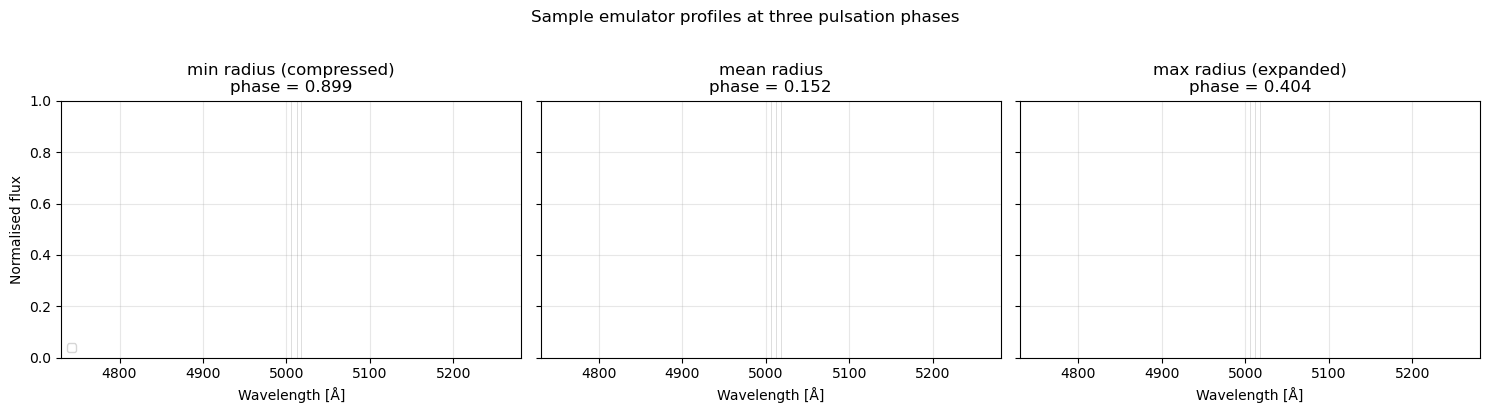

In [ ]:
# Pick three pulsation phases — minimum, mean, and maximum radius offset —
# so the panels span the most distinct atmospheric states.
example_phase_idx = [
    int(np.argmin(pulsation_offsets)),
    int(np.argmin(np.abs(pulsation_offsets - np.median(pulsation_offsets)))),
    int(np.argmax(pulsation_offsets)),
]
example_labels = ['min radius (compressed)', 'mean radius', 'max radius (expanded)']

fig, axes = plt.subplots(1, len(example_phase_idx),
                         figsize=(5 * len(example_phase_idx), 4),
                         sharey=True)
for ax, idx, lbl in zip(axes, example_phase_idx, example_labels):
    for variant in available_emulator_variants:
        wl, F = emulator_profiles[variant]
        ax.plot(wl, F[idx], color=EMULATOR_COLORS[variant], lw=0.9,
                alpha=0.85, label=variant)
    for lc in LINE_CENTRES:
        ax.axvline(lc, color='gray', alpha=0.3, lw=0.6)
    ax.set_xlabel('Wavelength [Å]')
    ax.set_title(f'{lbl}\nphase = {PHASE_NUMPY[idx]:.3f}')
    ax.grid(True, alpha=0.3)
axes[0].set_ylabel('Normalised flux')
axes[0].legend(fontsize=8, loc='lower left')
plt.suptitle('Sample emulator profiles at three pulsation phases', y=1.02)
plt.tight_layout(); plt.show()

KeyError: 'linear_interpolator'

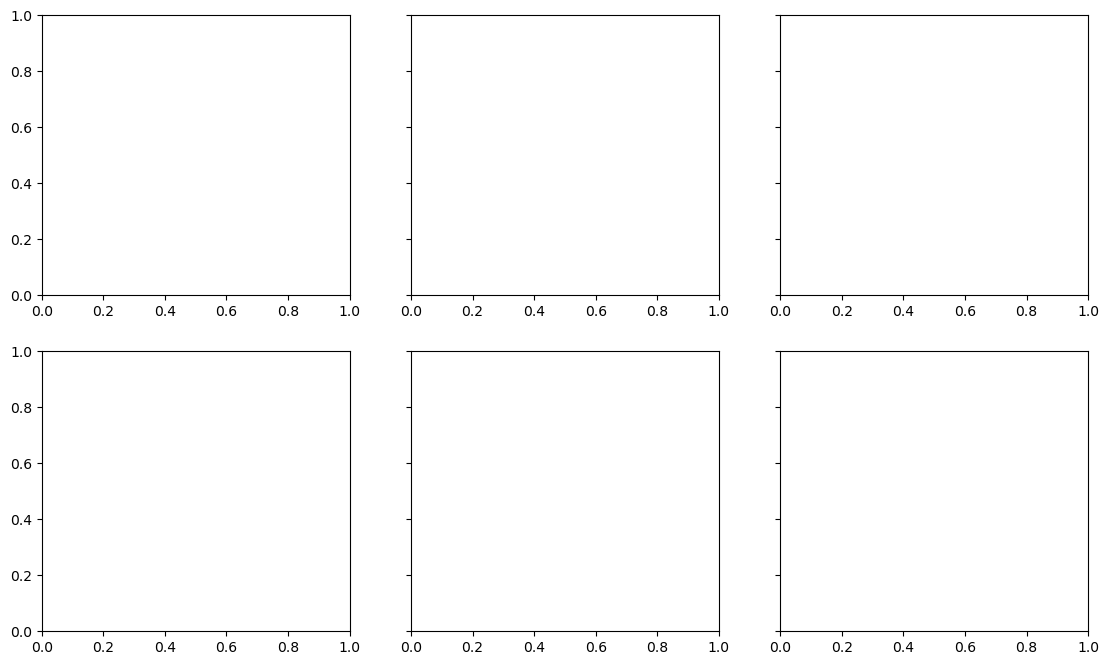

In [ ]:
# Zoom each optimised Fe I window at the mean-radius phase, and plot residuals vs the reference (in percentage).
mean_phase_idx = example_phase_idx[1]
mean_lbl = example_labels[1]

# First row: fluxes, Second row: relative flux residuals [%] w.r.t. the reference variant
n_lines = len(FE_I_LINES)
fig, axes = plt.subplots(2, n_lines,
                         figsize=(4.5 * n_lines, 2 * 4),  # Make total height 8 for 2 rows
                         sharey='row')
if n_lines == 1:
    axes = np.array([[axes[0]], [axes[1]]])

ref_variant = 'linear_interpolator'
ref_wl, ref_F = emulator_profiles[ref_variant]

for col_idx, (name, lc, _) in enumerate(FE_I_LINES):
    key = name.replace('Fe I ', '')
    wl_lo, wl_hi = windows[key]
    # Top row: absolute fluxes
    ax_flux = axes[0, col_idx]
    for variant in available_emulator_variants:
        wl, F = emulator_profiles[variant]
        mask = (wl >= wl_lo) & (wl <= wl_hi)
        ax_flux.plot(wl[mask], F[mean_phase_idx, mask],
                     color=EMULATOR_COLORS[variant], lw=2.0,
                     linestyle=LINE_STYLES[variant],
                     alpha=0.9, label=variant.replace('_', ' ').replace('harps', 'HARPS'))
    ax_flux.axvline(lc, color='gray', ls=':', alpha=0.6)
    ax_flux.set_xlim(wl_lo, wl_hi)
    ax_flux.set_xlabel('Wavelength [Å]')
    ax_flux.set_title(f'{name}\n{mean_lbl}, phase = {PHASE_NUMPY[mean_phase_idx]:.3f}')
    ax_flux.grid(True, alpha=0.3)

    # Bottom row: percentage residuals with respect to the ensemble mean
    ax_resid = axes[1, col_idx]

    # Compute ensemble mean flux on a common grid (reference window grid)
    mask_ref = (ref_wl >= wl_lo) & (ref_wl <= wl_hi)
    window_grid = ref_wl[mask_ref]
    stacked_fluxes = []
    for variant in available_emulator_variants:
        wl, F = emulator_profiles[variant]
        interp_flux = np.interp(window_grid, wl, F[mean_phase_idx])
        stacked_fluxes.append(interp_flux)
    ensemble_flux = np.mean(stacked_fluxes, axis=0)

    for variant in available_emulator_variants:
        wl, F = emulator_profiles[variant]
        interp_flux = np.interp(window_grid, wl, F[mean_phase_idx])
        with np.errstate(divide='ignore', invalid='ignore'):
            pct_residual = 100 * (interp_flux - ensemble_flux) / ensemble_flux
            pct_residual = np.where(np.isfinite(pct_residual), pct_residual, 0.0)
        ax_resid.plot(window_grid, pct_residual,
                      color=EMULATOR_COLORS[variant], lw=2.0,
                      linestyle=LINE_STYLES[variant],
                      alpha=0.9, label=variant.replace('_', ' ').replace('harps', 'HARPS'))
    ax_resid.axhline(0, color='black', lw=0.7, alpha=0.6, ls=':')
    ax_resid.axvline(lc, color='gray', ls=':', alpha=0.6)
    ax_resid.set_xlim(wl_lo, wl_hi)
    ax_resid.set_xlabel('Wavelength [Å]')
    if col_idx == 0:
        ax_flux.set_ylabel('Normalised flux')
        ax_resid.set_ylabel('Flux difference [%]\nvs. ensemble mean')
    ax_resid.grid(True, alpha=0.3)
# Legends
axes[0,0].legend(fontsize=8, loc='lower left')
axes[1,0].legend(fontsize=8, loc='lower left')
plt.tight_layout(); plt.show()

In [ ]:
# Save the last matplotlib figure as a PDF
plt.savefig("cepheid_analysis_fe_lines_model_comparison.pdf", bbox_inches="tight", dpi=300)

<Figure size 640x480 with 0 Axes>

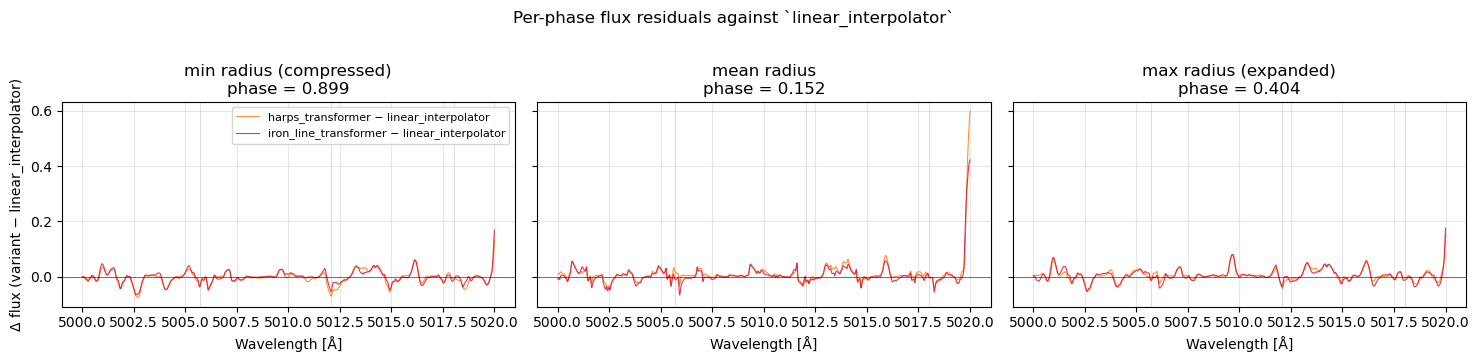

In [ ]:
# Flux residuals against the linear_interpolator reference, at the same example phases.
if REF_SPECTRA not in emulator_profiles:
    raise KeyError(f'{REF_SPECTRA!r} not in spectra_dataset — needed as reference for residuals')
ref_wl, ref_F = emulator_profiles[REF_SPECTRA]

fig, axes = plt.subplots(1, len(example_phase_idx),
                         figsize=(5 * len(example_phase_idx), 3.5),
                         sharey=True)
for ax, idx, lbl in zip(axes, example_phase_idx, example_labels):
    for variant in available_emulator_variants:
        if variant == REF_SPECTRA:
            continue
        F_v = _on_common_grid(variant, ref_wl)
        ax.plot(ref_wl, F_v[idx] - ref_F[idx],
                color=EMULATOR_COLORS[variant], lw=0.8,
                alpha=0.85, label=f'{variant} − linear_interpolator')
    ax.axhline(0, color='black', lw=0.6, alpha=0.6)
    for lc in LINE_CENTRES:
        ax.axvline(lc, color='gray', alpha=0.3, lw=0.6)
    ax.set_xlabel('Wavelength [Å]')
    ax.set_title(f'{lbl}\nphase = {PHASE_NUMPY[idx]:.3f}')
    ax.grid(True, alpha=0.3)
axes[0].set_ylabel('Δ flux (variant − linear_interpolator)')
axes[0].legend(fontsize=8, loc='best')
plt.suptitle('Per-phase flux residuals against `linear_interpolator`', y=1.02)
plt.tight_layout(); plt.show()

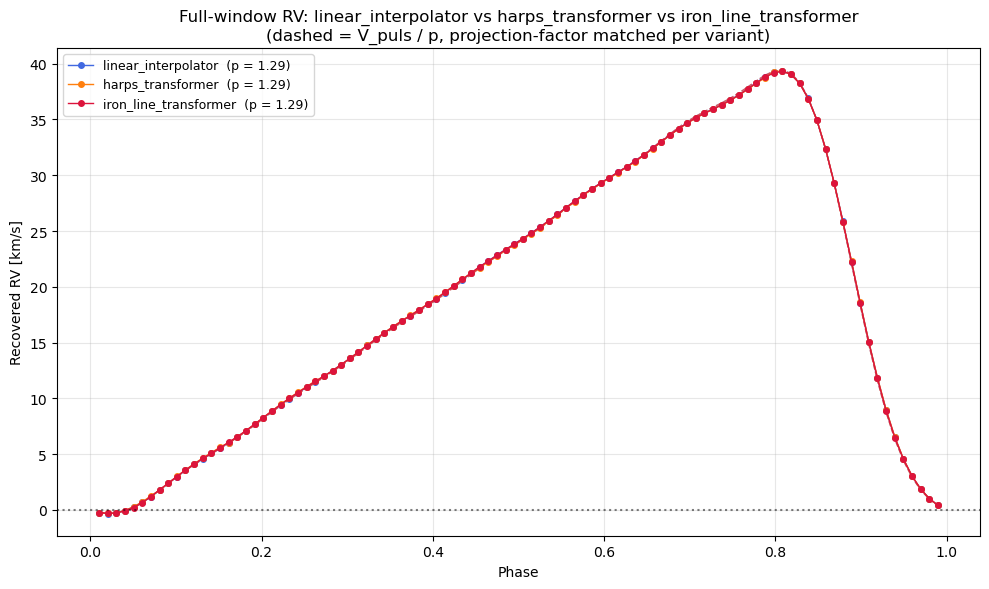

In [ ]:
# Recovered RV (full window) for each emulator vs the on-mesh truth.
truth_signed = pulsation_velocities - pulsation_velocities[0]

fig, ax = plt.subplots(figsize=(10, 6))
for variant in available_emulator_variants:
    rv = rv_table[variant]['full']
    p, _ = _best_p(rv, truth_signed)
    ax.plot(phases[1:-1], rv[1:-1], 'o-', ms=4,
            color=EMULATOR_COLORS[variant], lw=1.0,
            label=f'{variant}  (p = {p:.2f})')
    if np.isfinite(p) and p != 0:
        ax.plot(phases[1:-1], truth_signed[1:-1] / p,
                ls='--', lw=1.0, alpha=0.5, color=EMULATOR_COLORS[variant])

ax.axhline(0, color='black', linestyle=':', alpha=0.5)
ax.set_xlabel('Phase')
ax.set_ylabel('Recovered RV [km/s]')
ax.set_title('Full-window RV: linear_interpolator vs harps_transformer vs iron_line_transformer\n'
             '(dashed = V_puls / p, projection-factor matched per variant)')
ax.legend(fontsize=9, loc='best')
ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.show()